## Precipitation DownscalingDevelopment
Downscale the precipitation using SNOTEL data. Includes gap filling.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel, siteNLDAS
from buildforcing.downscale import downscalePrecipV1
import os

In [2]:
site = 'Taos Powderhorn'
isAlpine = False
downloadNLDAS = False

In [3]:
# Alpine Environmental Vars since it cannot load conda for some unknown reason
if isAlpine:
    os.environ['SNOTEL_PATH'] = '/projects/ccox1@xsede.org/data/snotel'
    os.environ['NLDAS_PATH'] = '/projects/ccox1@xsede.org/data/nldas'

### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [4]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 36.5819511, Longitude: -105.4561691


In [5]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 2010-10-01 to 2021-09-30


In [6]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

In [ ]:
snotel_data.head()

Load NLDAS data

In [9]:
nldas = siteNLDAS(snotel.site_name, start_date=datetime.combine(start_date,time(0,0)), end_date=datetime.combine(end_date,time(23,0)),storage_path=os.environ['NLDAS_PATH'])
nldas.loadNetCDF()

In [ ]:
nldas.data.tail()

In [10]:
nldas_hourly_precip = nldas.data['Rainf'].tz_convert(snotel_data.index.tz)

In [11]:
nldas_precip_daily = nldas_hourly_precip.resample('D').sum()

#### Visualization

In [ ]:
snotel_data.head()

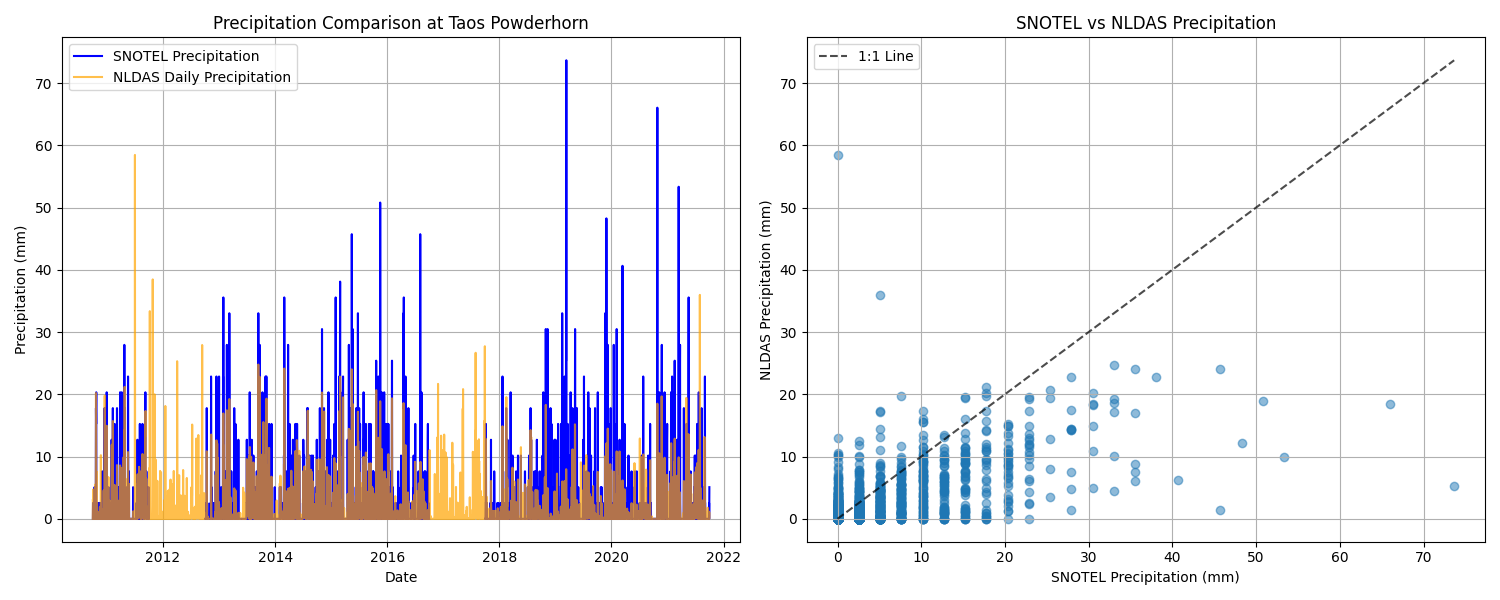

In [12]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time series comparison
ax1.plot(snotel_data.index, snotel_data['precip_mm'], label='SNOTEL Precipitation', color='blue')
ax1.plot(nldas_precip_daily.index, nldas_precip_daily, label='NLDAS Daily Precipitation', color='orange', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm)')
ax1.set_title(f'Precipitation Comparison at {site}')
ax1.legend()
ax1.grid(True)

# Plot 2: Scatter plot
# Create a common date range for both datasets
# Find overlapping dates by using the indexes directly
common_dates = pd.DatetimeIndex(sorted(set(snotel_data.index) & set(nldas_precip_daily.index)))

# Extract the precipitation data for the common dates
snotel_precip = snotel_data.loc[common_dates, 'precip_mm']
nldas_precip = nldas_precip_daily.loc[common_dates]

# Create scatter plot
ax2.scatter(snotel_precip, nldas_precip, alpha=0.5)
ax2.set_xlabel('SNOTEL Precipitation (mm)')
ax2.set_ylabel('NLDAS Precipitation (mm)')
ax2.set_title('SNOTEL vs NLDAS Precipitation')

# Add 1:1 line
max_val = max(snotel_precip.max(), nldas_precip.max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 Line')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


Monthly analysis

In [13]:
# Resample to monthly totals, remove timezone since it is not needed for monthly data
snotel_monthly = snotel_data['precip_mm'].tz_localize(None).resample('ME').sum()
nldas_monthly = nldas_precip_daily.tz_localize(None).resample('ME').sum()

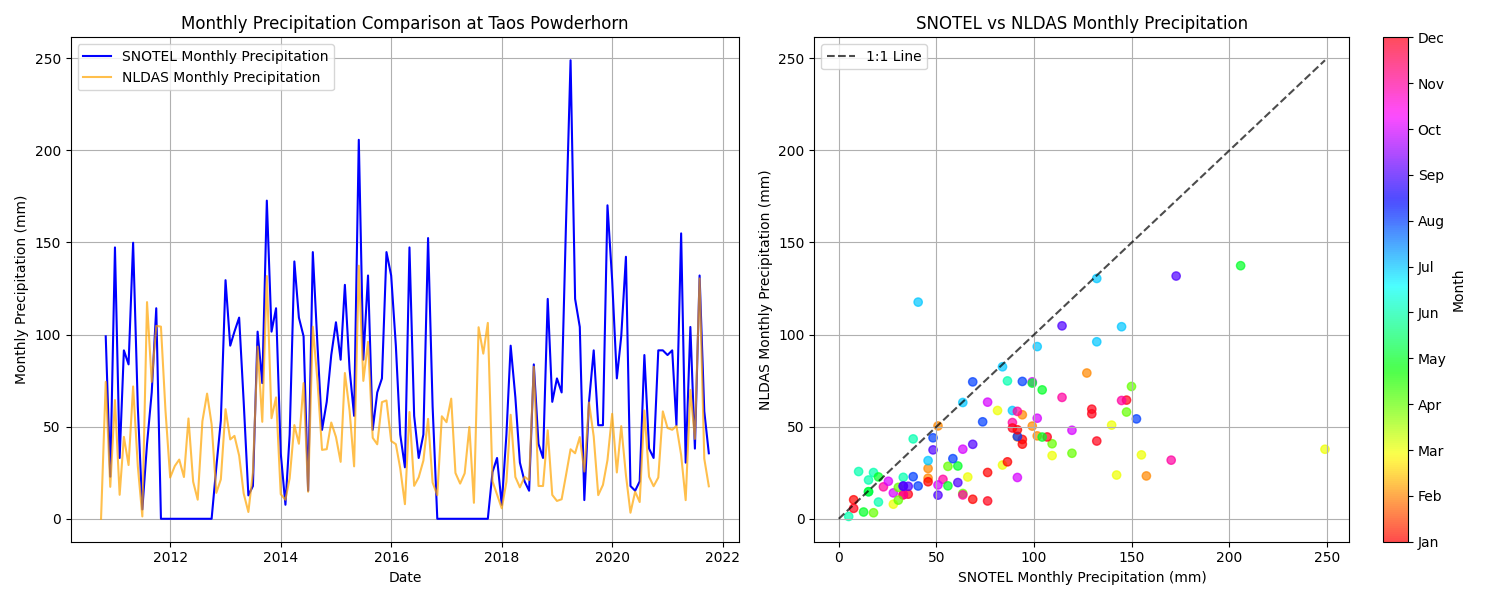

In [17]:
# Monthly totals and scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Monthly time series comparison
ax1.plot(snotel_monthly.index, snotel_monthly, label='SNOTEL Monthly Precipitation', color='blue')
ax1.plot(nldas_monthly.index, nldas_monthly, label='NLDAS Monthly Precipitation', color='orange', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Monthly Precipitation (mm)')
ax1.set_title(f'Monthly Precipitation Comparison at {site}')
ax1.legend()
ax1.grid(True)
# Plot 2: Monthly scatter plot
# Create a common date range for both datasets
common_months = pd.DatetimeIndex(sorted(set(snotel_monthly.index) & set(nldas_monthly.index)))

# Extract the precipitation data for the common months
snotel_precip = snotel_monthly.loc[common_months]
nldas_precip = nldas_monthly.loc[common_months]

# Remove months with zero precipitation in snotel because it is indicative of missing data
valid_indices = snotel_precip > 0
snotel_precip = snotel_precip[valid_indices]
nldas_precip = nldas_precip[valid_indices]
common_months = common_months[valid_indices]

# Create scatter plot with colors by month
months = [date.month for date in common_months]
scatter = ax2.scatter(snotel_precip, nldas_precip, c=months, cmap='hsv', alpha=0.7)
ax2.set_xlabel('SNOTEL Monthly Precipitation (mm)')
ax2.set_ylabel('NLDAS Monthly Precipitation (mm)')
ax2.set_title('SNOTEL vs NLDAS Monthly Precipitation')

# Add colorbar to show month legend
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))
cbar.set_ticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add 1:1 line
max_val = max(snotel_precip.max(), nldas_precip.max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 Line')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


### Algorithm Development and Testing

In [ ]:
nldas_test_precip = nldas_hourly_precip.loc['2004':'2020']
nldas_corrected = downscalePrecipV1(nldas_test_precip, snotel.data['precip_mm'])

Visualize the results

In [ ]:
# Plot a year of hourly data
plt.figure(figsize=(12, 6))
nldas_test_precip.plot(label='NLDAS Hourly Precipitation', color='orange', alpha=0.7)
nldas_corrected.plot(label='Downscaled Hourly Precipitation', color='blue', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title('NLDAS vs Downscaled Hourly Precipitation - January 2018')
plt.legend()
plt.show()

In [ ]:
# Compare a year of NLDAS corrected to SNOTEL daily
nldas_compare = nldas_corrected['2018']
nldas_compare = nldas_compare.tz_convert(snotel_data.index.tz)

fig, ax = plt.subplots(figsize=(12, 6))
snotel_data['precip_mm']['2018'].plot(ax=ax, label='SNOTEL Daily Precipitation', color='blue')
nldas_compare.plot(ax=ax, label='Downscaled Daily Precipitation', color='orange', alpha=0.7)
nldas_compare_daily = nldas_compare.resample('D').sum()
nldas_compare_daily.plot(ax=ax, label='Downscaled Daily Precipitation (Daily Sum)', color='green', alpha=0.7)
ax.set_xlabel('Date')

Compare the downscaled data to the original snotel data

In [ ]:
nldas_downscaled_daily = nldas_hourly['downscaled'].resample('D').sum()
nldas_downscaled_daily.name = 'nldas_downscaled_daily'

In [ ]:
plt.figure(figsize=(8, 6))
nldas_downscaled_daily.plot(label='Downscaled Daily Precipitation', color='green', alpha=0.7)
snotel_data['precip_mm'].plot(label='SNOTEL Daily Precipitation', color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title('NLDAS Downscaled vs SNOTEL Daily Precipitation')
plt.legend()
plt.show()

Compare histograms of the downscaled and SNOTEL data

In [ ]:
# Plot histograms of the downscaled and SNOTEL data
plt.figure(figsize=(10, 6))
plt.hist(snotel_data['precip_mm'].dropna(), bins=30, alpha=0.5, label='SNOTEL Precipitation', color='blue', density=True)
plt.hist(nldas_downscaled_daily.dropna(), bins=30, alpha=0.5, label='Downscaled Precipitation', color='green', density=True)
plt.xlabel('Daily Precipitation (mm)')